# Week 4 — Data Loading & Exploration

This notebook covers the first project milestone:
- Parse RAVDESS filenames into a structured metadata table
- Verify file counts
- Visualize class distributions

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Parse Filenames into Metadata Table

Each RAVDESS filename encodes 7 fields separated by dashes:

| Position | Meaning | Values |
|----------|---------|--------|
| 1 | Modality | 03 = audio-only |
| 2 | Vocal channel | 01 = speech, 02 = song |
| 3 | **Emotion** | 01–08 (our target) |
| 4 | Intensity | 01 = normal, 02 = strong |
| 5 | Statement | 01 or 02 |
| 6 | Repetition | 01 or 02 |
| 7 | Actor | 01–24 (odd = male, even = female) |

In [2]:
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised',
}

CHANNEL_MAP = {'01': 'speech', '02': 'song'}
INTENSITY_MAP = {'01': 'normal', '02': 'strong'}

DATA_DIR = '../../data'

records = []
for actor_dir in sorted(os.listdir(DATA_DIR)):
    actor_path = os.path.join(DATA_DIR, actor_dir)
    if not os.path.isdir(actor_path):
        continue
    for fname in sorted(os.listdir(actor_path)):
        if not fname.endswith('.wav'):
            continue
        parts = fname.replace('.wav', '').split('-')
        if len(parts) != 7:
            continue
        modality, channel, emotion, intensity, statement, repetition, actor = parts
        records.append({
            'filepath': os.path.join(actor_path, fname),
            'filename': fname,
            'modality': modality,
            'channel': CHANNEL_MAP.get(channel, channel),
            'emotion_id': emotion,
            'emotion': EMOTION_MAP.get(emotion, emotion),
            'intensity': INTENSITY_MAP.get(intensity, intensity),
            'statement': statement,
            'repetition': repetition,
            'actor': int(actor),
            'gender': 'male' if int(actor) % 2 == 1 else 'female',
        })

df = pd.DataFrame(records)
print(f'Total files parsed: {len(df)}')
df.head()

Total files parsed: 2452


,filepath,filename,modality,channel,emotion_id,emotion,intensity,statement,repetition,actor,gender
0,../../data\Actor_01\03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,03,speech,01,neutral,normal,01,01,1,male
1,../../data\Actor_01\03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,03,speech,01,neutral,normal,01,02,1,male
2,../../data\Actor_01\03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,03,speech,01,neutral,normal,02,01,1,male
3,../../data\Actor_01\03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,03,speech,01,neutral,normal,02,02,1,male
4,../../data\Actor_01\03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,03,speech,02,calm,normal,01,01,1,male


## 2. Verify File Counts

Expected: 1,440 speech files + 1,012 song files = 2,452 total.

In [3]:
print('Files by vocal channel:')
print(df['channel'].value_counts().to_string())
print(f'\nTotal: {len(df)}')
print(f'\nActors represented: {df["actor"].nunique()} (expected 24)')
print(f'\nEmotions represented: {df["emotion"].nunique()} (expected 8)')

Files by vocal channel:
channel
speech    1440
song      1012

Total: 2452

Actors represented: 24 (expected 24)

Emotions represented: 8 (expected 8)


## 3. Class Distribution — Emotion Labels

We want to know how balanced the dataset is across the 8 emotion classes. Imbalanced classes can bias classifiers toward the majority class, which we'll need to account for in evaluation (using macro-F1, not just accuracy).

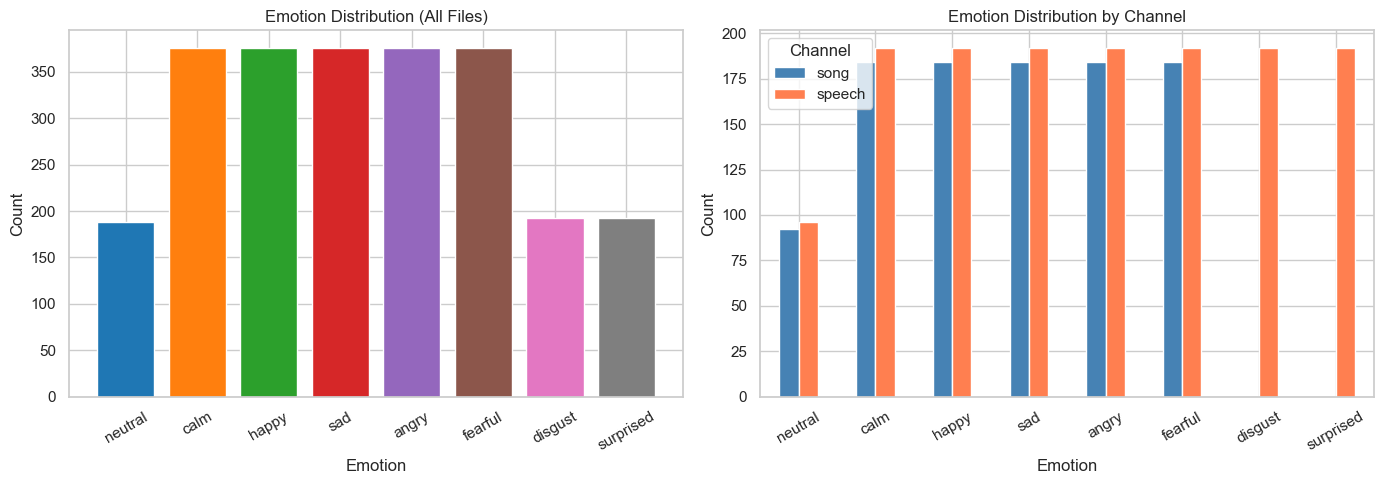

Plot saved to outputs/class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall emotion counts
emotion_counts = df['emotion'].value_counts().reindex(EMOTION_MAP.values(), fill_value=0)
axes[0].bar(emotion_counts.index, emotion_counts.values, color=sns.color_palette('tab10', 8))
axes[0].set_title('Emotion Distribution (All Files)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Emotion counts split by speech vs song
pivot = df.groupby(['emotion', 'channel']).size().unstack(fill_value=0)
pivot = pivot.reindex(EMOTION_MAP.values(), fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Emotion Distribution by Channel')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Channel')

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/class_distribution.png')

**Observation:** Neutral only appears in speech (not song), which is why it has fewer total files. The remaining 7 emotions appear in both speech and song tracks. The dataset is reasonably balanced across emotions, but neutral is underrepresented — something to watch when interpreting per-class metrics.

## 4. Distribution by Actor and Gender

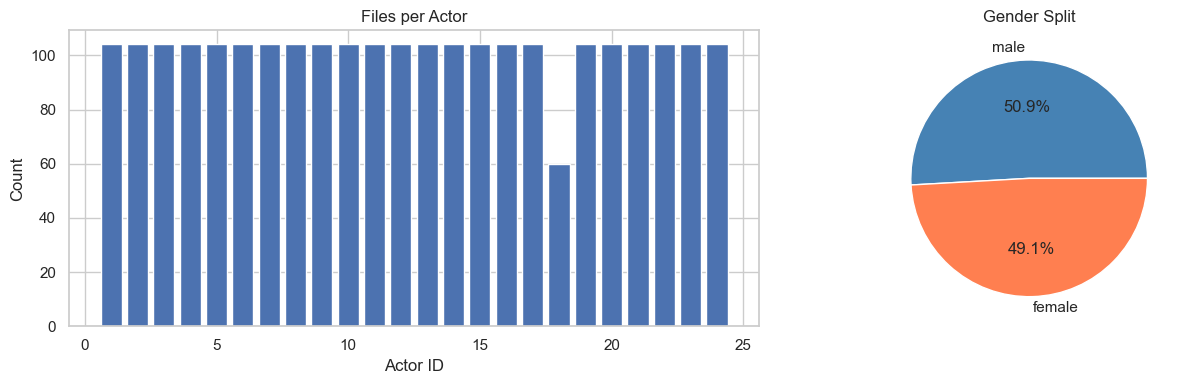

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Files per actor
actor_counts = df.groupby('actor').size()
axes[0].bar(actor_counts.index, actor_counts.values)
axes[0].set_title('Files per Actor')
axes[0].set_xlabel('Actor ID')
axes[0].set_ylabel('Count')

# Gender split
gender_counts = df['gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Gender Split')

plt.tight_layout()
plt.savefig('../outputs/actor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Actor 18 has fewer files because they have no song recordings. The dataset is gender-balanced (12 male, 12 female actors).

## 5. Save Metadata Table

In [6]:
os.makedirs('../outputs', exist_ok=True)
df.to_csv('../outputs/metadata.csv', index=False)
print('Metadata saved to outputs/metadata.csv')
print(df.dtypes)
df.describe(include='all')

Metadata saved to outputs/metadata.csv
filepath      object
filename      object
modality      object
channel       object
emotion_id    object
emotion       object
intensity     object
statement     object
repetition    object
actor          int64
gender        object
dtype: object


,filepath,filename,modality,channel,emotion_id,emotion,intensity,statement,repetition,actor,gender
count,2452,2452,2452,2452,2452,2452,2452,2452,2452,2452.000000,2452
unique,2452,2452,1,2,8,8,2,2,2,NaN,2
top,../../data\Actor_24\03-02-06-02-02-02-24.wav,03-02-06-02-02-02-24.wav,03,speech,02,calm,normal,01,01,NaN,male
freq,1,1,2452,1440,376,376,1320,1226,1226,NaN,1248
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.401305,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.945763,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,NaN
